### Chains using LangGraph
In this section we will see how we can build a simple chain using LangGraph that uses 4 concepts:
- How to use chat messages as our Graph State
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tool calls in our graph nodes

In [28]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

### Messages - ChatMessages as our StateGraph

We can use messages which can be used to capture 

### Tools in LangGraph

In [29]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11d004650>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11d006000>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [30]:
def add(a: int, b: int) -> int:
    """
    Adds two intergers together.

    Args:
        a (int): The first integer to add.
        b (int): The second integer to add.

    Returns:
        int: The sum of the two integers.
    """
    return a + b
    

In [31]:
# Binding tool with llm
from langchain_core.messages import HumanMessage

llm_with_tools = llm.bind_tools([add])
tool_calls = llm_with_tools.invoke([
    HumanMessage(content="What is 457867349478 + 8924398743895?", name="user")
])

In [32]:
tool_calls.tool_calls

[{'name': 'add',
  'args': {'a': 457867349478, 'b': 8924398743895},
  'id': 'e7yzy92gc',
  'type': 'tool_call'}]

In [33]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


### Reducers with add_messages

In [34]:
initial_messages = [AIMessage(content="Tell me how can i help you?", name="GAssist")]
initial_messages.append(HumanMessage(content="I want to learn about coding.", name="Anurag"))

initial_messages

[AIMessage(content='Tell me how can i help you?', additional_kwargs={}, response_metadata={}, name='GAssist', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn about coding.', additional_kwargs={}, response_metadata={}, name='Anurag')]

In [35]:
ai_message = AIMessage(content="Sure! What programming language are you interested in?", name="GAssist")
ai_message

AIMessage(content='Sure! What programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='GAssist', tool_calls=[], invalid_tool_calls=[])

In [36]:
add_messages(initial_messages, ai_message)

[AIMessage(content='Tell me how can i help you?', additional_kwargs={}, response_metadata={}, name='GAssist', id='d96716a8-97ba-420f-a4ff-23516cc6245e', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn about coding.', additional_kwargs={}, response_metadata={}, name='Anurag', id='6aa5b4be-d7ce-49ec-9103-e6c6c3332138'),
 AIMessage(content='Sure! What programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='GAssist', id='7c2e244c-02bb-4f96-ad0a-bcc1bb3206b7', tool_calls=[], invalid_tool_calls=[])]

In [37]:
def llm_tool(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["messages"])
        ]
    }

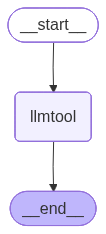

In [38]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("llmtool", llm_tool)
builder.add_edge(START, "llmtool")
builder.add_edge("llmtool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
# Invocation
import pprint
messages = graph.invoke({
    "messages": "What is 43 + 6859?"
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 43 + 6859?
================================== Ai Message ==================================
Tool Calls:
  add (48n3xwp6h)
 Call ID: 48n3xwp6h
  Args:
    a: 43
    b: 6859


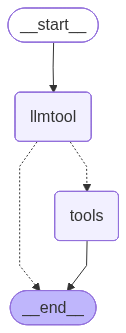

In [40]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

# Add Nodes
builder.add_node("tools", ToolNode(tools=[add]))
builder.add_node("llmtool", llm_tool)

# Add Edges
builder.add_edge(START, "llmtool")
builder.add_conditional_edges(
    "llmtool",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
# Invocation
import pprint
messages = graph.invoke({
    "messages": "What is 43 + 6859?"
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 43 + 6859?
================================== Ai Message ==================================
Tool Calls:
  add (94n9r4kjw)
 Call ID: 94n9r4kjw
  Args:
    a: 43
    b: 6859
================================= Tool Message =================================
Name: add

6902


In [43]:
messages = graph.invoke({
    "messages": "What is the mathematical expression for Perceptron?"
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the mathematical expression for Perceptron?
================================== Ai Message ==================================

The mathematical expression for a Perceptron is given by:

y = θ0 + θ1x1 + θ2x2 + ... + θnxn

where y is the output of the Perceptron (either 0 or 1), θ0, θ1, θ2, ..., θn are the weights (including the bias term), and x1, x2, ..., xn are the input features.

In vector form, this can be represented as:

y = θ0 + θT x

where θT is the transpose of the weight vector, and x is the input vector.

The Perceptron updates its weights based on the following rule:

θi ← θi + η(xi * (yi - θT x))

where η is the learning rate, xi is the ith input feature, and yi is the target output.
